# 1 - Data Preprocessing

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import sklearn.cluster as cluster
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel(r"C:\Users\sangm\Documents\EastWestAirlines.xlsx",sheet_name='data')
df.head(3)

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0


In [3]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [4]:
print(df.describe())

               ID#       Balance    Qual_miles    cc1_miles    cc2_miles  \
count  3999.000000  3.999000e+03   3999.000000  3999.000000  3999.000000   
mean   2014.819455  7.360133e+04    144.114529     2.059515     1.014504   
std    1160.764358  1.007757e+05    773.663804     1.376919     0.147650   
min       1.000000  0.000000e+00      0.000000     1.000000     1.000000   
25%    1010.500000  1.852750e+04      0.000000     1.000000     1.000000   
50%    2016.000000  4.309700e+04      0.000000     1.000000     1.000000   
75%    3020.500000  9.240400e+04      0.000000     3.000000     1.000000   
max    4021.000000  1.704838e+06  11148.000000     5.000000     3.000000   

         cc3_miles    Bonus_miles  Bonus_trans  Flight_miles_12mo  \
count  3999.000000    3999.000000   3999.00000        3999.000000   
mean      1.012253   17144.846212     11.60190         460.055764   
std       0.195241   24150.967826      9.60381        1400.209171   
min       1.000000       0.000000      

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [6]:
df.drop(['ID#'],axis=1, inplace=True)
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


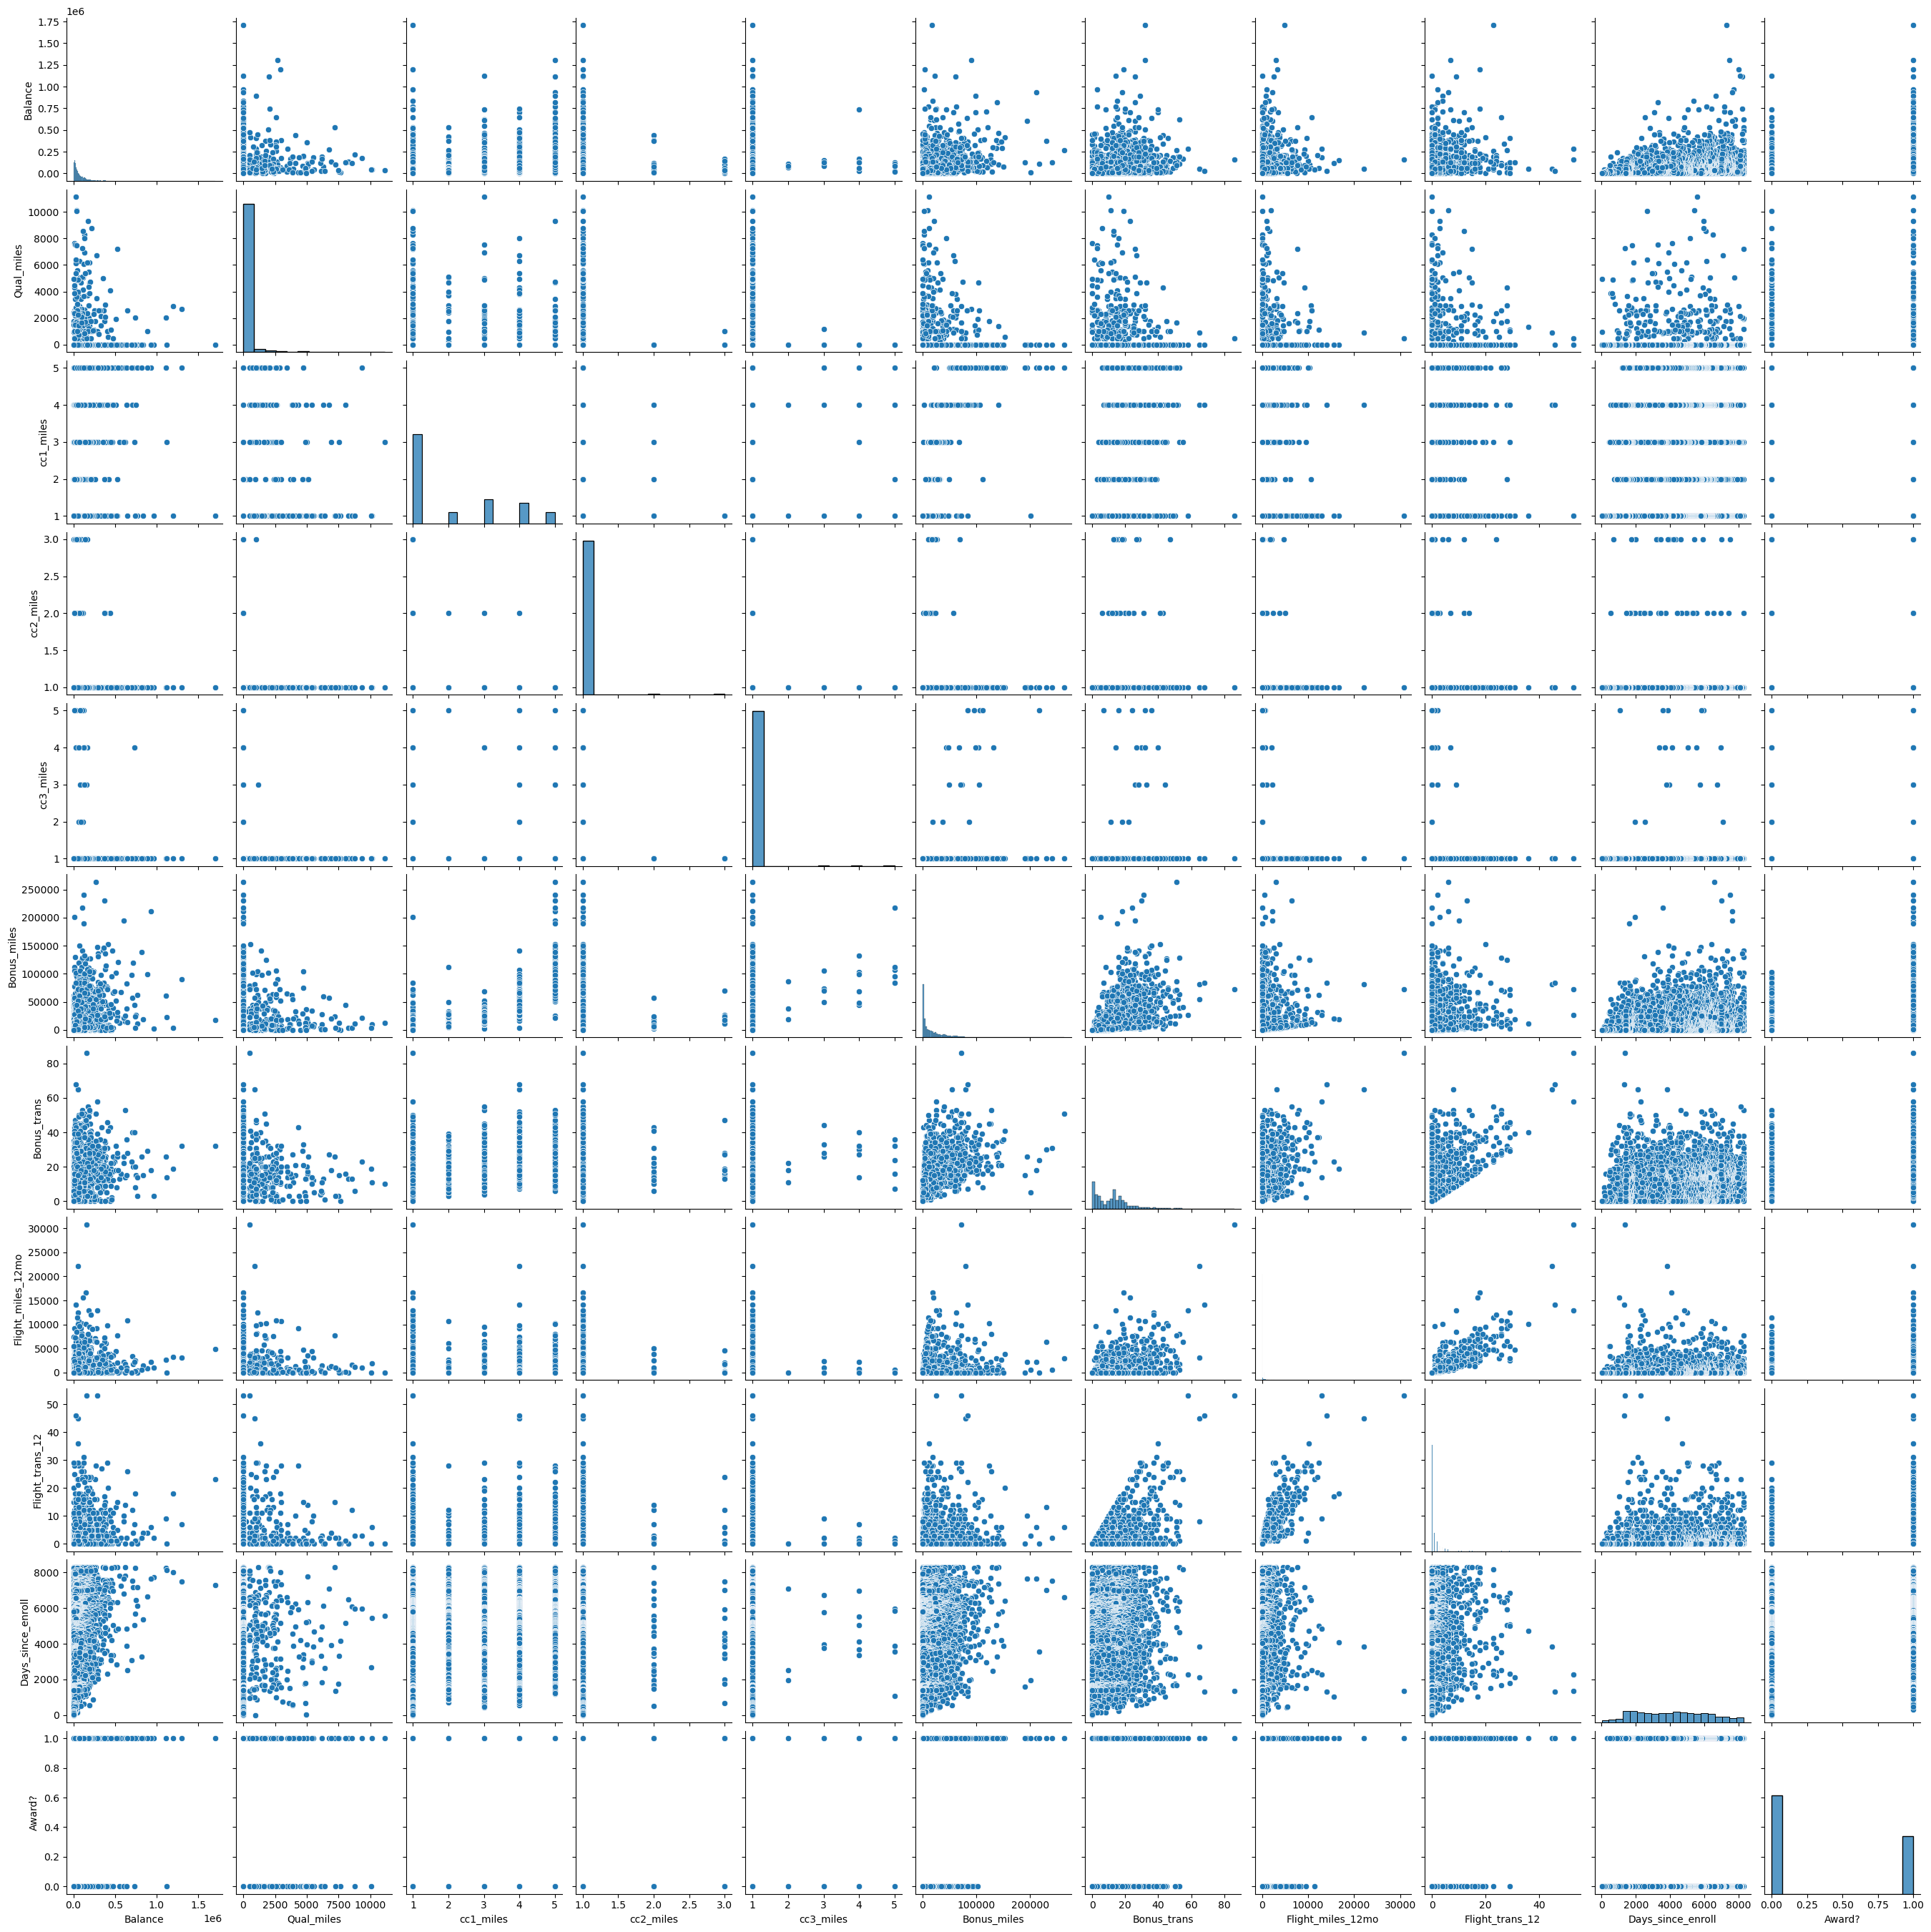

In [7]:
# 2. Visualizations
sns.pairplot(data=df)
plt.show()

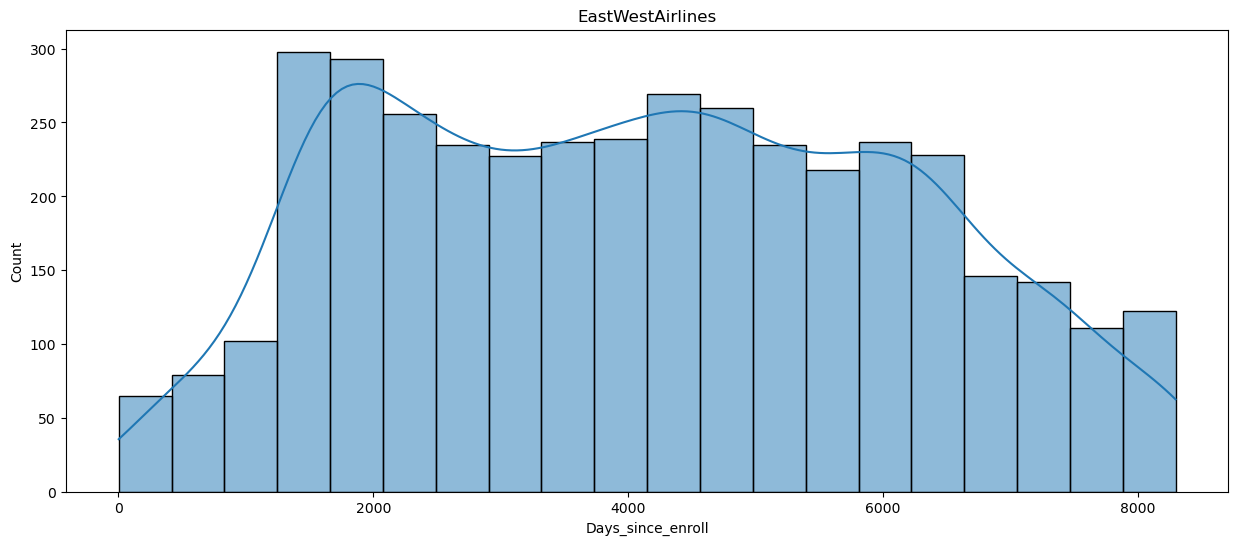

In [8]:
# Example: Histogram
plt.figure(figsize=(15, 6))
sns.histplot(df['Days_since_enroll'], kde=True)
plt.title('EastWestAirlines')
plt.show()

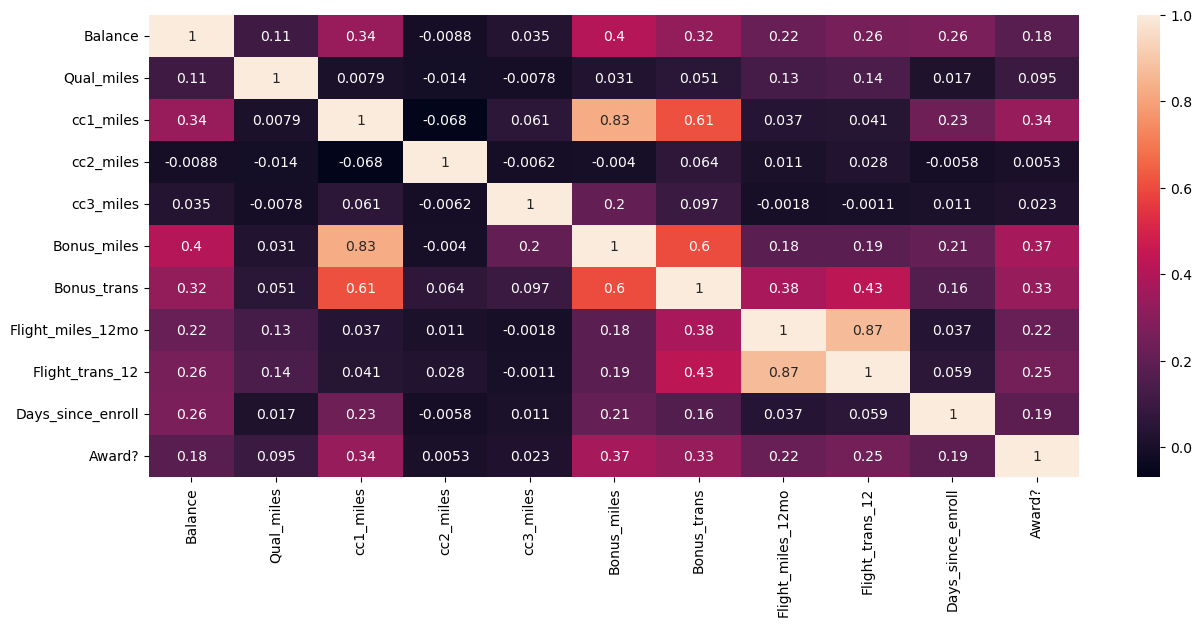

In [9]:
plt.figure(figsize=(15, 6))
heat = df
sns.heatmap(data=heat.corr(),annot=True)
plt.show()

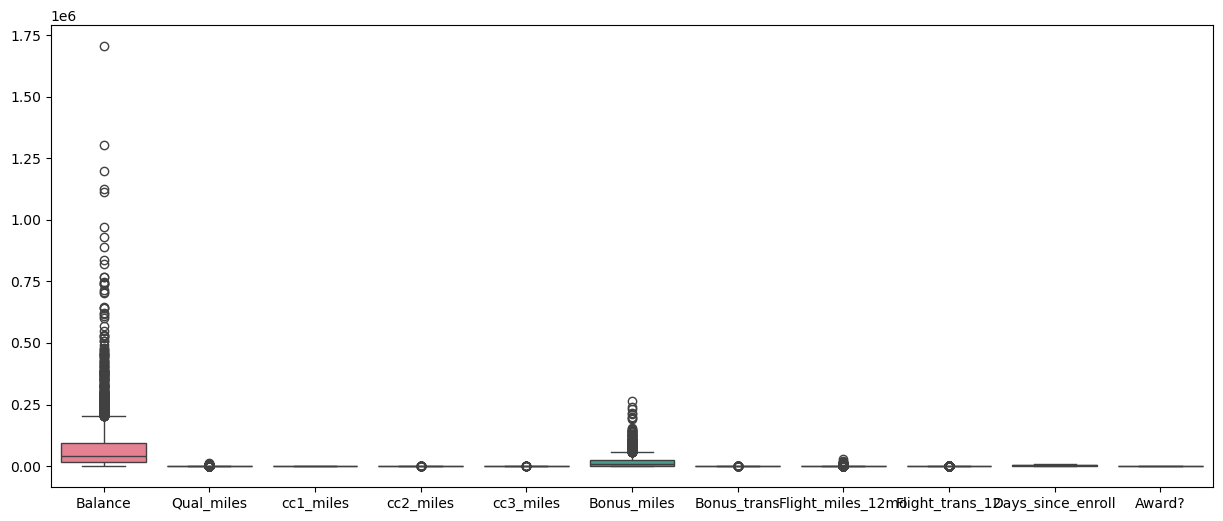

In [10]:
 #Box plot for outlier detection
plt.figure(figsize=(15, 6))
sns.boxplot(data=df)
plt.show()

# Standarize the data

In [11]:
scalar=MinMaxScaler()
scaled_df=scalar.fit_transform(df)

In [12]:
print(scaled_df)

[[0.01650773 0.         0.         ... 0.         0.84374246 0.        ]
 [0.01128788 0.         0.         ... 0.         0.83988425 0.        ]
 [0.02425685 0.         0.         ... 0.         0.84784181 0.        ]
 ...
 [0.0431695  0.         0.5        ... 0.         0.16879672 1.        ]
 [0.03220189 0.         0.         ... 0.01886792 0.16867615 0.        ]
 [0.00176908 0.         0.         ... 0.         0.16831444 0.        ]]


In [13]:
scaled_df1=pd.DataFrame(scaled_df,columns=df.columns)
scaled_df1.head()  

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,0.016508,0.0,0.00,0.0,0.0,0.000660,0.011628,0.000000,0.000000,0.843742,0.0
1,0.011288,0.0,0.00,0.0,0.0,0.000815,0.023256,0.000000,0.000000,0.839884,0.0
2,0.024257,0.0,0.00,0.0,0.0,0.015636,0.046512,0.000000,0.000000,0.847842,0.0
3,0.008667,0.0,0.00,0.0,0.0,0.001896,0.011628,0.000000,0.000000,0.837955,0.0
4,0.057338,0.0,0.75,0.0,0.0,0.164211,0.302326,0.067398,0.075472,0.835905,1.0


# Hierarchical Clustering

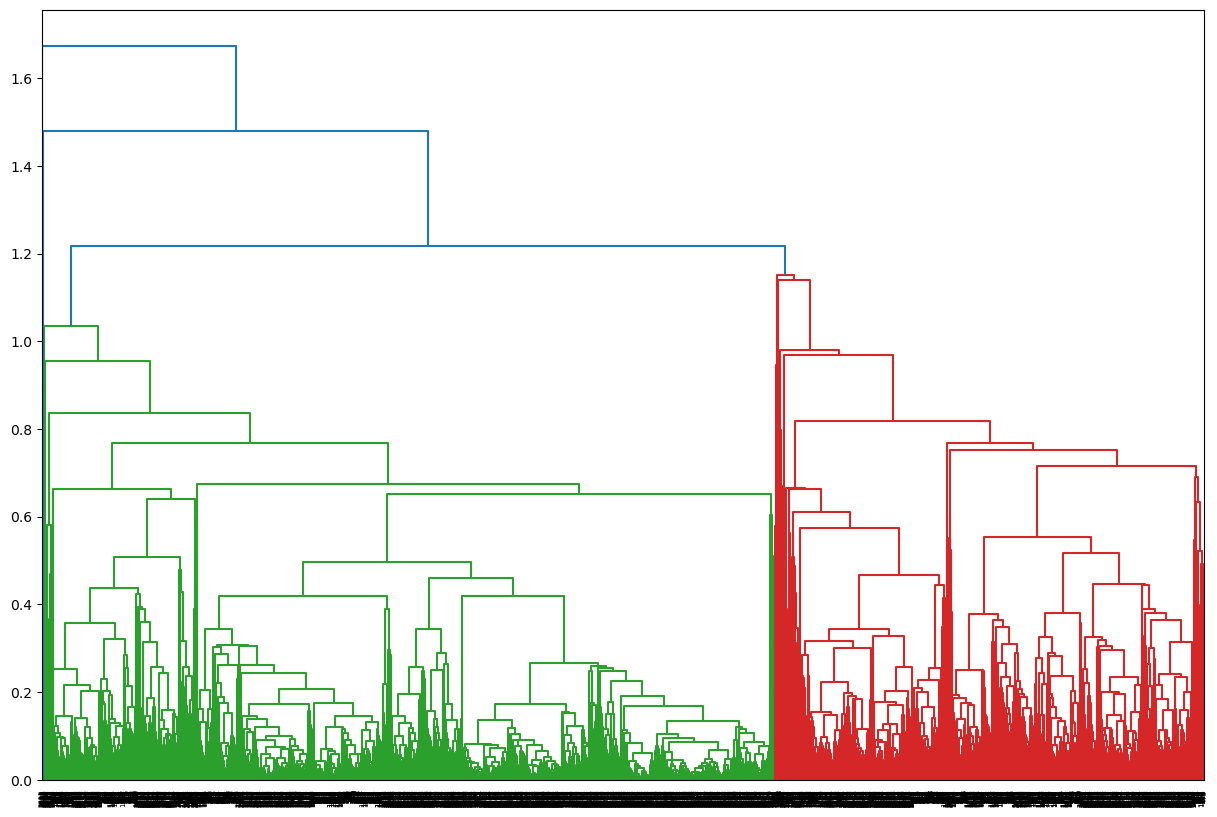

In [14]:
plt.figure(figsize=(15, 10))
dendrogram = sch.dendrogram(sch.linkage(scaled_df1, method='average'))

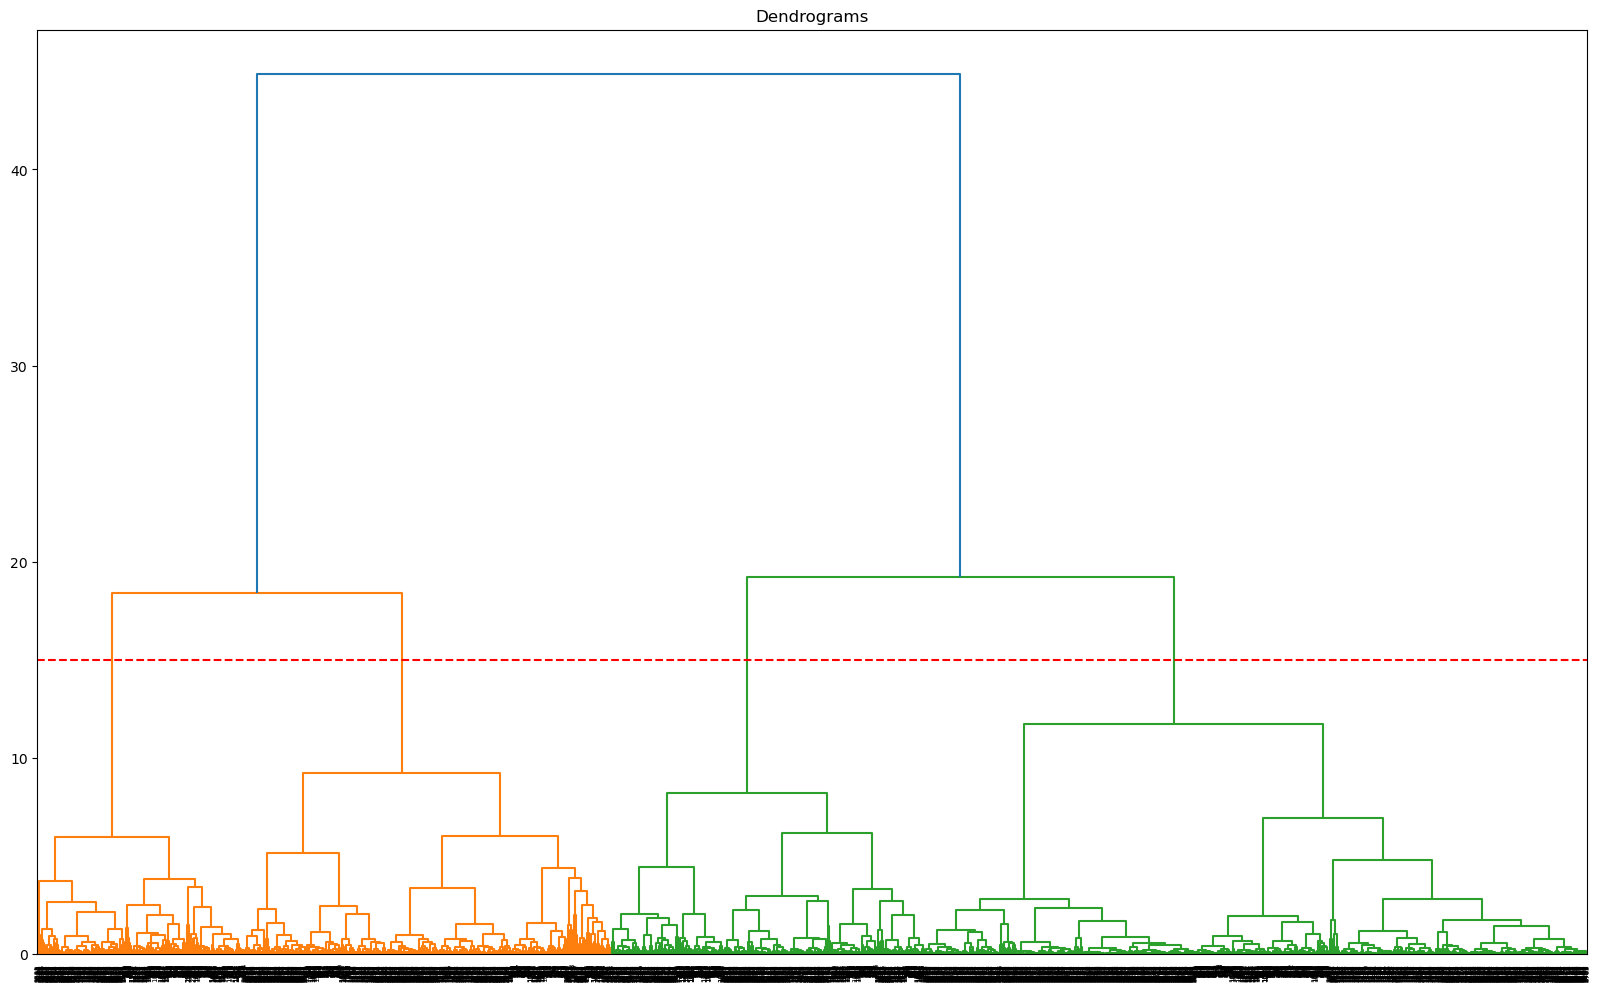

In [15]:
plt.figure(figsize=(20, 12))  
plt.title("Dendrograms")  
dend = sch.dendrogram(sch.linkage(scaled_df1, method='ward'))
plt.axhline(y=15, color='r', linestyle='--')
plt.show()

In [22]:
# create clusters
hc = AgglomerativeClustering(n_clusters=4, linkage = 'single',metric='euclidean')

In [23]:
y_hc = hc.fit_predict(df)
Clusters=pd.DataFrame(y_hc,columns=['Clusters'])

In [24]:
Clusters.value_counts()

Clusters
0           3994
1              3
2              1
3              1
Name: count, dtype: int64

In [25]:
df['hc_clust']= Clusters
df.iloc[:,1:7].groupby(df.hc_clust).mean()

,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans
hc_clust,,,,,,
0,142.382073,2.058338,1.014522,1.012268,17117.363545,11.585628
1,1644.666667,3.000000,1.000000,1.000000,29243.000000,19.666667
2,2706.000000,5.000000,1.000000,1.000000,90653.000000,32.000000
3,0.000000,1.000000,1.000000,1.000000,17108.000000,32.000000


Text(0.5, 0.98, 'Relative comparison of customers in respective clusters')

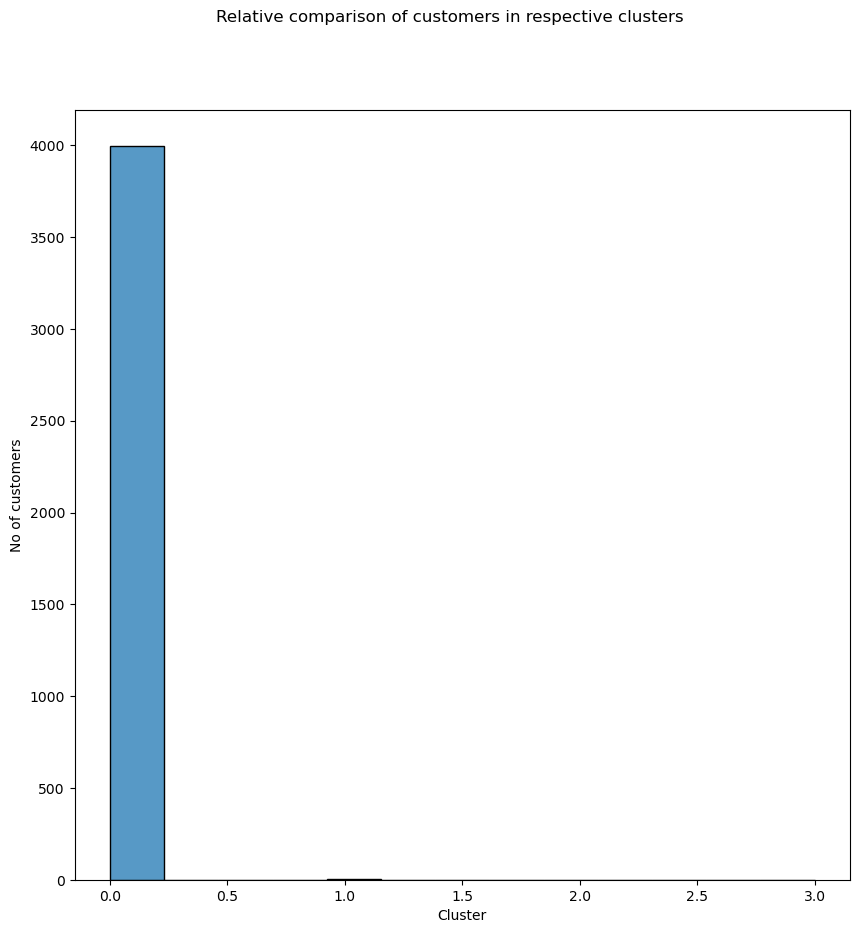

In [26]:
plt.figure(figsize=(10,10))
sns.histplot (x='hc_clust', data=df)
plt.xlabel('Cluster')
plt.ylabel('No of customers')
plt.suptitle('Relative comparison of customers in respective clusters')

# Implementing Clustering Algorithms: Kmeans Clustering

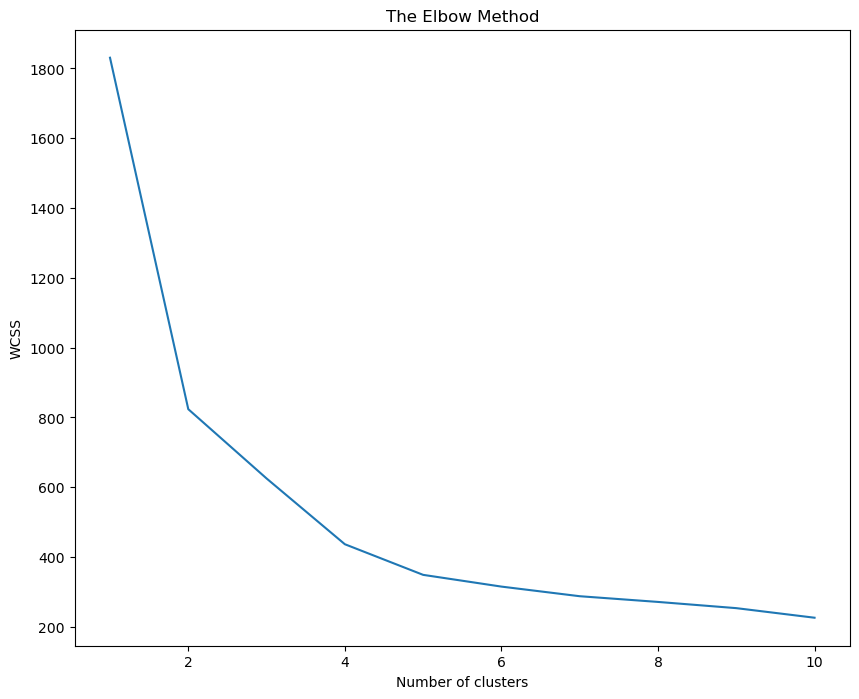

In [27]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 200)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)
    
plt.figure(figsize=(10, 8)) 
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [32]:
for i in range(3,13):
    labels=cluster.KMeans(n_clusters=i,init="k-means++",random_state=200).fit(scaled_df).labels_
    print ("Silhouette score for k(clusters) = "+str(i)+" is "
           +str(metrics.silhouette_score(scaled_df1,labels,metric="euclidean",sample_size=1000,random_state=200)))

Silhouette score for k(clusters) = 3 is 0.45748332355557725
Silhouette score for k(clusters) = 4 is 0.46521656243534165
Silhouette score for k(clusters) = 5 is 0.4331034289974864
Silhouette score for k(clusters) = 6 is 0.38763888823092263
Silhouette score for k(clusters) = 7 is 0.38645918789675876
Silhouette score for k(clusters) = 8 is 0.37610003937995123
Silhouette score for k(clusters) = 9 is 0.3324285112669356
Silhouette score for k(clusters) = 10 is 0.3394798052631412
Silhouette score for k(clusters) = 11 is 0.34134516809334947
Silhouette score for k(clusters) = 12 is 0.34476121246430746


In [33]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)
k_means = kmeans.fit_predict(scaled_df1)

In [34]:
k_means

array([1, 1, 1, ..., 3, 1, 1])

In [35]:
k_means1=k_means
k_cluster = list(k_means1)

In [36]:
df['k_cluster'] = k_cluster

In [37]:
kmeans_mean_cluster = pd.DataFrame(round(df.groupby('k_cluster').mean(),1))

In [38]:
kmeans_mean_cluster

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,hc_clust
k_cluster,,,,,,,,,,,,
0,83529.2,290.5,1.2,1.0,1.0,8850.4,10.5,1030.1,3.1,4338.9,1.0,0.0
1,40520.8,90.0,1.1,1.0,1.0,3315.8,6.5,226.7,0.7,3605.1,0.0,0.0
2,117976.5,80.4,3.6,1.0,1.0,31073.5,17.2,225.0,0.6,4470.7,0.0,0.0
3,108317.4,198.3,3.9,1.0,1.0,45609.7,20.2,713.7,2.1,4863.4,1.0,0.0


In [39]:
pd.DataFrame(round(df.groupby('k_cluster').count(),1))

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,hc_clust
k_cluster,,,,,,,,,,,,
0,673,673,673,673,673,673,673,673,673,673,673,673
1,1891,1891,1891,1891,1891,1891,1891,1891,1891,1891,1891,1891
2,627,627,627,627,627,627,627,627,627,627,627,627
3,808,808,808,808,808,808,808,808,808,808,808,808


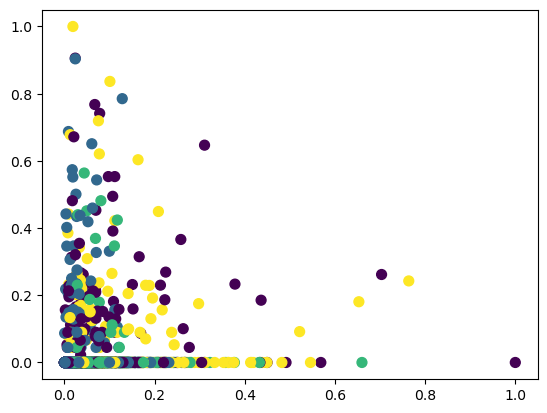

In [40]:
plt.scatter(scaled_df[:, 0], scaled_df[:, 1], c=k_means, s=50, cmap='viridis')

# DBSCAN Clustering

In [41]:
dbscan = DBSCAN(eps=2.5, min_samples=21)
dbscan.fit(scaled_df)

DBSCAN(eps=2.5, min_samples=21)

In [42]:
dbscan.labels_

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [43]:
df['DBSCAN_labels'] = dbscan.labels_
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,hc_clust,k_cluster,DBSCAN_labels
0,28143,0,1,1,1,174,1,0,0,7000,0,0,1,0
1,19244,0,1,1,1,215,2,0,0,6968,0,0,1,0
2,41354,0,1,1,1,4123,4,0,0,7034,0,0,1,0
3,14776,0,1,1,1,500,1,0,0,6952,0,0,1,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1,0,3,0
